<a href="https://colab.research.google.com/github/Lochtejs/Lidzhi_Ochirov/blob/master/Lab1_Ochirov_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
pip install PyIRI

In [8]:
pip install pymsis

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import PyIRI
from scipy.signal import find_peaks
import PyIRI.edp_update as ml
import pymsis

In [14]:
# Задаем исходные данные для расчета ионосферы
year = 2020
day = 1
alon = np.array([61.])  # Челябинск
ahr = np.array([12.0])  # Полдень

# Высоты
alt_num = 100
alt_min = 90
alt_max = 700
aalt = np.linspace(alt_min, alt_max, alt_num)

# Солнечная активность
f107_low = 72
f107_mid = 100
f107_high = 200

# Сезоны и широты
seasons = [(1,1), (4,1), (7,1), (10,1)]  # янв, апр, июл, окт
latitudes = [0, 55, 80]  # экватор, Челябинск, Арктика

print("Исходные данные готовы")


Исходные данные готовы


1. Влияние солнечной активности (Челябинск, июль)


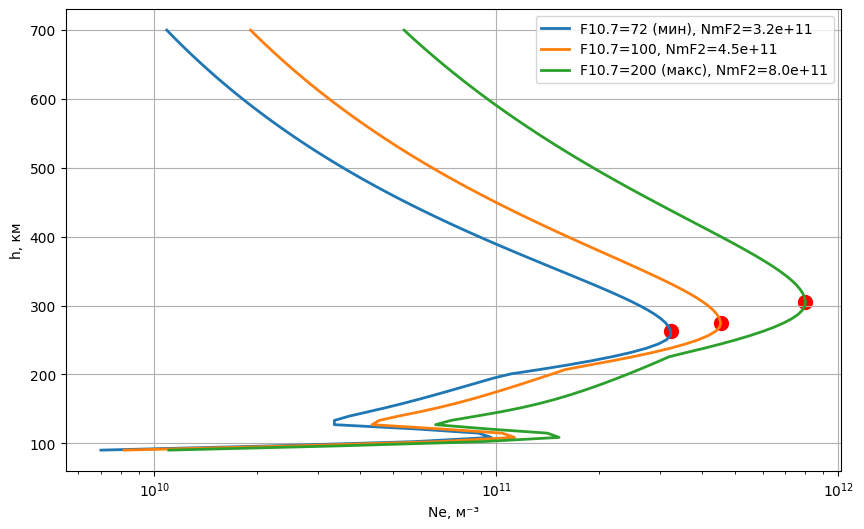

In [15]:
# 1. Влияние солнечной активности (Челябинск, июль)
print("1. Влияние солнечной активности (Челябинск, июль)")
fig, ax = plt.subplots(1, 1, figsize=(10,6))

for f107, label in zip([f107_low, f107_mid, f107_high],
                      ['F10.7=72 (мин)', 'F10.7=100', 'F10.7=200 (макс)']):
    _, _, _, _, _, _, edp = ml.IRI_density_1day(year, 7, day, ahr, alon,
                                               np.array([55.]), aalt, f107,
                                               PyIRI.coeff_dir, 1)
    ne = edp[0,:,0]

    peak_idx = np.argmax(ne)
    hmF2 = aalt[peak_idx]
    NmF2 = ne[peak_idx]

    ax.plot(ne, aalt, linewidth=2, label=f'{label}, NmF2={NmF2:.1e}')
    ax.scatter(NmF2, hmF2, s=100, c='red')

ax.set_xscale('log')
ax.grid()
ax.set_xlabel('Ne, м⁻³')
ax.set_ylabel('h, км')
ax.legend()
plt.show()


2. Влияние сезона (Челябинск, F10.7=100)


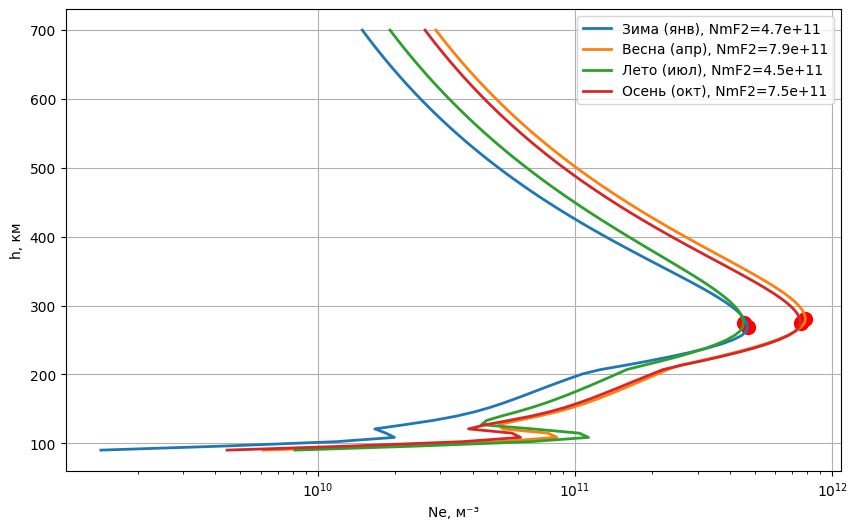

In [16]:
# 2. Влияние сезона (Челябинск, F10.7=100)
print("2. Влияние сезона (Челябинск, F10.7=100)")
fig, ax = plt.subplots(1, 1, figsize=(10,6))

season_names = ['Зима (янв)', 'Весна (апр)', 'Лето (июл)', 'Осень (окт)']
for i, (month, _) in enumerate(seasons):
    _, _, _, _, _, _, edp = ml.IRI_density_1day(year, month, day, ahr, alon,
                                               np.array([55.]), aalt, f107_mid,
                                               PyIRI.coeff_dir, 1)
    ne = edp[0,:,0]

    peak_idx = np.argmax(ne)
    hmF2 = aalt[peak_idx]
    NmF2 = ne[peak_idx]

    ax.plot(ne, aalt, linewidth=2, label=f'{season_names[i]}, NmF2={NmF2:.1e}')
    ax.scatter(NmF2, hmF2, s=100, c='red')

ax.set_xscale('log')
ax.grid()
ax.set_xlabel('Ne, м⁻³')
ax.set_ylabel('h, км')
ax.legend()
plt.show()

3. Форма профиля по широтам (июль, F10.7=100)


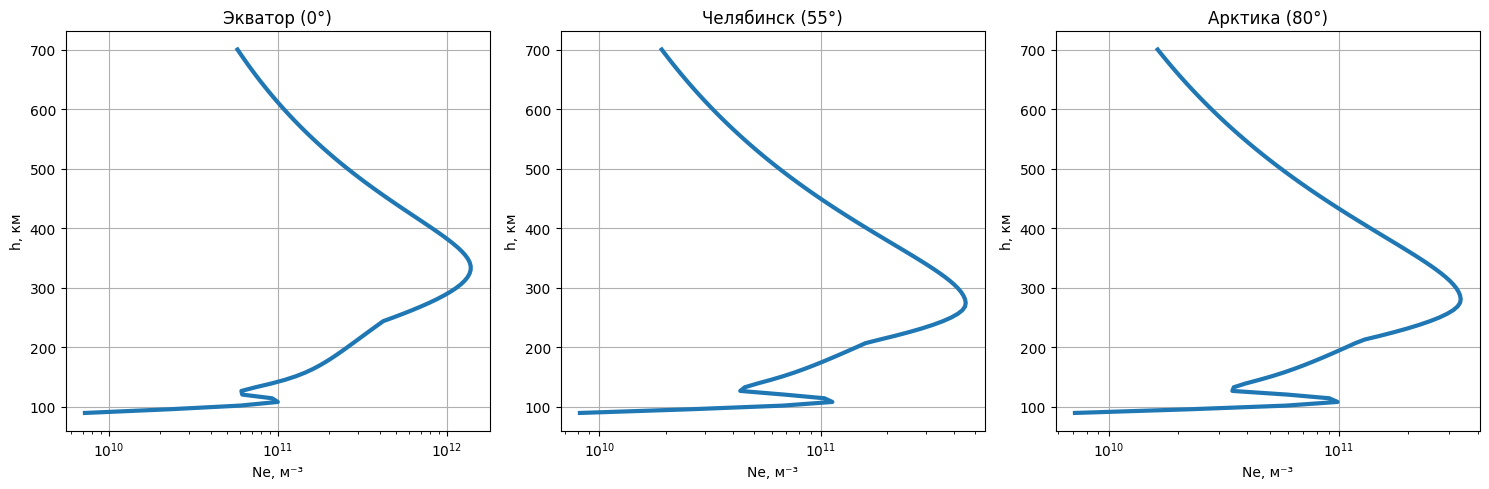

In [18]:
# 3. Форма профиля по широтам (июль, F10.7=100)
print("3. Форма профиля по широтам (июль, F10.7=100)")
fig, axes = plt.subplots(1, 3, figsize=(15,5))

lat_names = ['Экватор (0°)', 'Челябинск (55°)', 'Арктика (80°)']
for i, alat in enumerate(latitudes):
    _, _, _, _, _, _, edp = ml.IRI_density_1day(year, 7, day, ahr, alon,
                                               np.array([alat]), aalt, f107_mid,
                                               PyIRI.coeff_dir, 1)
    ne = edp[0,:,0]

    axes[i].plot(ne, aalt, linewidth=3)
    axes[i].set_xscale('log')
    axes[i].grid()
    axes[i].set_xlabel('Ne, м⁻³')
    axes[i].set_ylabel('h, км')
    axes[i].set_title(lat_names[i])

plt.tight_layout()
plt.show()


In [19]:
# 4. Сводная таблица F2-слоя
print("4. СВОДНАЯ ТАБЛИЦА F2-СЛОЯ")
print("Сезон\tF10.7\tШирота\thmF2\tNmF2")
print("-"*50)

for month_name, (month, _) in zip(['Зима','Весна','Лето','Осень'], seasons):
    for f107_name, f107 in zip(['Низкая','Средняя','Высокая'], [f107_low,f107_mid,f107_high]):
        for lat_name, alat in zip(['Низкие','Средние','Высокие'], latitudes):
            _, _, _, _, _, _, edp = ml.IRI_density_1day(year, month, day, ahr, alon,
                                                       np.array([alat]), aalt, f107,
                                                       PyIRI.coeff_dir, 1)
            ne = edp[0,:,0]

            peak_idx = np.argmax(ne)
            hmF2 = aalt[peak_idx]
            NmF2 = ne[peak_idx]

            print(f"{month_name}\t{f107_name}\t{lat_name}\t{hmF2:.0f}\t{NmF2:.1e}")


4. СВОДНАЯ ТАБЛИЦА F2-СЛОЯ
Сезон	F10.7	Широта	hmF2	NmF2
--------------------------------------------------
Зима	Низкая	Низкие	343	8.1e+11
Зима	Низкая	Средние	250	2.1e+11
Зима	Низкая	Высокие	275	9.3e+10
Зима	Средняя	Низкие	380	1.1e+12
Зима	Средняя	Средние	269	4.7e+11
Зима	Средняя	Высокие	293	1.9e+11
Зима	Высокая	Низкие	460	2.0e+12
Зима	Высокая	Средние	312	1.4e+12
Зима	Высокая	Высокие	336	5.4e+11
Весна	Низкая	Низкие	336	1.4e+12
Весна	Низкая	Средние	256	4.6e+11
Весна	Низкая	Высокие	275	2.4e+11
Весна	Средняя	Низкие	367	1.7e+12
Весна	Средняя	Средние	281	7.9e+11
Весна	Средняя	Высокие	293	3.9e+11
Весна	Высокая	Низкие	441	2.7e+12
Весна	Высокая	Средние	330	1.8e+12
Весна	Высокая	Высокие	336	8.4e+11
Лето	Низкая	Низкие	306	1.0e+12
Лето	Низкая	Средние	263	3.2e+11
Лето	Низкая	Высокие	275	2.7e+11
Лето	Средняя	Низкие	336	1.4e+12
Лето	Средняя	Средние	275	4.5e+11
Лето	Средняя	Высокие	281	3.4e+11
Лето	Высокая	Низкие	398	2.3e+12
Лето	Высокая	Средние	306	8.0e+11
Лето	Высокая	Высокие	293	5.2e+11
Осень	Низка